In [1]:
import pandas as pd 
import numpy as np

In [4]:
file_path = '/Users/mohsen/Desktop/nyc_duration_prediction/data/raw/yellow_tripdata_2026-01.parquet'

In [5]:
raw_data = pd.read_parquet(file_path)

In [6]:
raw_data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,None,237,161,0,17.09,0.00,0.5,0.00,0.0,1.0,21.84,NaN,NaN,0.75
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,None,42,42,0,23.19,0.00,0.5,0.00,0.0,1.0,24.69,NaN,NaN,0.00
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,None,137,69,0,29.21,0.00,0.5,0.00,0.0,1.0,33.96,NaN,NaN,0.75
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,None,137,162,0,19.19,0.00,0.5,0.00,0.0,1.0,23.94,NaN,NaN,0.75


In [94]:
raw_data.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

In [95]:
type(raw_data['tpep_pickup_datetime'])

pandas.Series

In [96]:
duration = raw_data['tpep_dropoff_datetime'] - raw_data['tpep_pickup_datetime']

In [97]:
p_data = raw_data

In [98]:
p_data['duration'] = raw_data['tpep_dropoff_datetime'] - raw_data['tpep_pickup_datetime']

In [99]:
p_data['duration'] = (p_data['duration'].dt.total_seconds() / 60).round(2)

In [100]:
p_data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,5.55
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75,5.72
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75,8.88
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,42.80
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,13.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,NaN,237,161,0,...,0.00,0.5,0.00,0.0,1.0,21.84,NaN,NaN,0.75,13.27
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,NaN,42,42,0,...,0.00,0.5,0.00,0.0,1.0,24.69,NaN,NaN,0.00,0.23
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,NaN,137,69,0,...,0.00,0.5,0.00,0.0,1.0,33.96,NaN,NaN,0.75,15.78
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,NaN,137,162,0,...,0.00,0.5,0.00,0.0,1.0,23.94,NaN,NaN,0.75,9.65


In [101]:
p_data['tpep_pickup_datetime'] = pd.to_datetime(p_data['tpep_pickup_datetime'])
p_data['pickup_hour'] = p_data['tpep_pickup_datetime'].dt.hour
p_data['pickup_dayofweek'] = p_data['tpep_pickup_datetime'].dt.dayofweek

def categorize_hour(hour):
    if 0 <= hour <= 5:
        return 'late_night'
    elif 6 <= hour <= 9:
        return 'morning_peak'
    elif 10 <= hour <= 15:
        return 'midday'
    elif 16 <= hour <= 19:
        return 'evening_peak'
    else:
        return 'night'

p_data['is_weekend'] = p_data['pickup_dayofweek'].isin([6])
p_data['hour_category'] = p_data['pickup_hour'].apply(categorize_hour)
p_data['is_rush_hour'] = p_data['pickup_hour'].isin([5,6,7,8,9,10])
p_data.dropna()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration,pickup_hour,pickup_dayofweek,is_weekend,hour_category,is_rush_hour
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,15.86,2.5,0.0,0.00,5.55,0,3,False,late_night,False
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,13.65,2.5,0.0,0.75,5.72,0,3,False,late_night,False
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,18.95,2.5,0.0,0.75,8.88,0,3,False,late_night,False
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,55.56,2.5,0.0,0.75,42.80,0,3,False,late_night,False
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,23.10,2.5,0.0,0.75,13.50,0,3,False,late_night,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2636826,1,2026-01-31 23:52:51,2026-02-01 00:08:38,1.0,0.00,1.0,N,249,142,1,...,23.10,2.5,0.0,0.75,15.78,23,5,False,night,False
2636827,2,2026-01-31 23:19:40,2026-01-31 23:30:21,1.0,1.86,1.0,N,230,239,1,...,21.06,2.5,0.0,0.75,10.68,23,5,False,night,False
2636828,2,2026-01-31 23:31:52,2026-01-31 23:46:55,1.0,2.66,1.0,N,239,262,1,...,26.62,2.5,0.0,0.00,15.05,23,5,False,night,False
2636829,2,2026-01-31 23:30:25,2026-01-31 23:34:10,4.0,0.36,1.0,N,170,170,1,...,12.55,2.5,0.0,0.75,3.75,23,5,False,night,False


In [102]:
p_data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration,pickup_hour,pickup_dayofweek,is_weekend,hour_category,is_rush_hour
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,15.86,2.5,0.0,0.00,5.55,0,3,False,late_night,False
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,13.65,2.5,0.0,0.75,5.72,0,3,False,late_night,False
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,18.95,2.5,0.0,0.75,8.88,0,3,False,late_night,False
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,55.56,2.5,0.0,0.75,42.80,0,3,False,late_night,False
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,23.10,2.5,0.0,0.75,13.50,0,3,False,late_night,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,NaN,237,161,0,...,21.84,NaN,NaN,0.75,13.27,23,5,False,night,False
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,NaN,42,42,0,...,24.69,NaN,NaN,0.00,0.23,23,5,False,night,False
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,NaN,137,69,0,...,33.96,NaN,NaN,0.75,15.78,23,5,False,night,False
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,NaN,137,162,0,...,23.94,NaN,NaN,0.75,9.65,23,5,False,night,False


In [103]:
print("تعداد رکورد قبل از تمیزکاری:", len(p_data))

# ========================
# مرحله ۱: مدت زمان سفر
# ========================
# حذف مدت زمان منفی، صفر یا خیلی طولانی (بیش از ۳ ساعت)
p_data = p_data[(p_data['duration'] > 0) & (p_data['duration'] <= 180)]

# ========================
# مرحله ۲: فاصله سفر
# ========================
p_data = p_data[p_data['trip_distance'] > 0]

# ========================
# مرحله ۳: تعداد مسافر
# ========================
p_data = p_data[(p_data['passenger_count'] > 0) & (p_data['passenger_count'] <= 6)]

# ========================
# مرحله ۴: حذف مقادیر گمشده در ستون‌های مهم
# ========================
p_data = p_data.dropna(subset=[
    'trip_distance', 
    'PULocationID', 
    'DOLocationID', 
    'duration',
    'passenger_count'
])

print("تعداد رکورد بعد از تمیزکاری اولیه:", len(p_data))

تعداد رکورد قبل از تمیزکاری: 3724889
تعداد رکورد بعد از تمیزکاری اولیه: 2544124


In [104]:
# بررسی وضعیت فعلی
print("\n--- آمار توصیفی duration ---")
print(p_data['duration'].describe())

print("\n--- آمار توصیفی trip_distance ---")
print(p_data['trip_distance'].describe())

print("\n--- تعداد NaN باقی‌مانده ---")
print(p_data.isnull().sum())


--- آمار توصیفی duration ---
count    2.544124e+06
mean     1.686650e+01
std      1.508127e+01
min      2.000000e-02
25%      7.480000e+00
50%      1.238000e+01
75%      2.062000e+01
max      1.799700e+02
Name: duration, dtype: float64

--- آمار توصیفی trip_distance ---
count    2.544124e+06
mean     3.510167e+00
std      6.640854e+01
min      1.000000e-02
25%      9.800000e-01
50%      1.670000e+00
75%      3.320000e+00
max      9.877358e+04
Name: trip_distance, dtype: float64

--- تعداد NaN باقی‌مانده ---
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0


In [105]:
final_features = [
    'trip_distance', 'PULocationID', 'DOLocationID', 
    'passenger_count', 'RatecodeID',
    'pickup_dayofweek', 'is_weekend', 'is_rush_hour', 'hour_category',
    'duration'
]
model_data = p_data[final_features].copy()

همبستگی ویژگی‌ها با duration:
duration            1.000000
RatecodeID          0.499051
trip_distance       0.053090
is_rush_hour        0.046577
passenger_count    -0.002480
is_weekend         -0.050824
pickup_dayofweek   -0.054848
Name: duration, dtype: float64


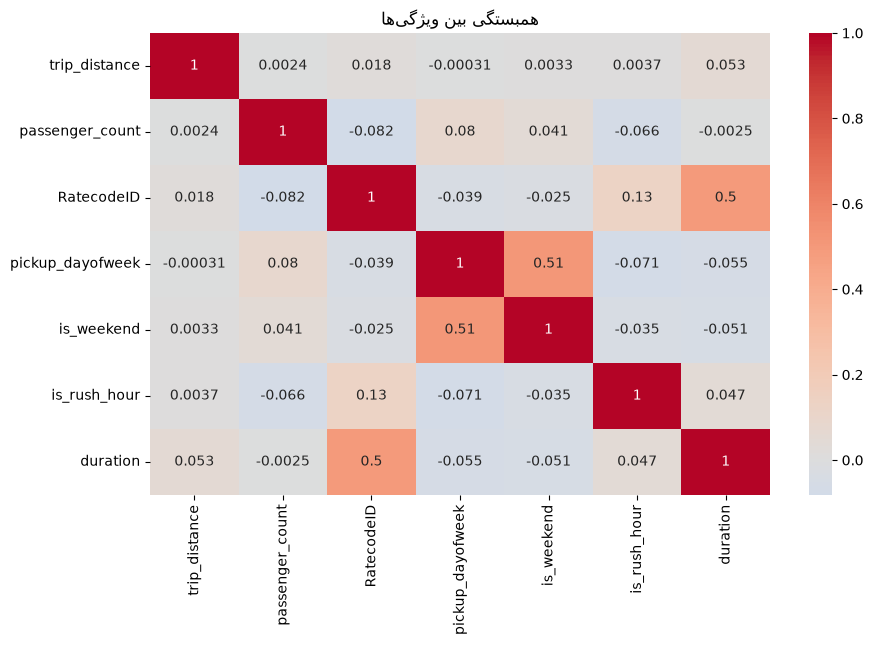

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# فقط ستون‌های عددی
numeric_cols = ['trip_distance', 'passenger_count', 'RatecodeID', 
                'pickup_dayofweek', 'is_weekend', 'is_rush_hour', 'duration']

corr = model_data[numeric_cols].corr()

# نمایش همبستگی با duration
print("همبستگی ویژگی‌ها با duration:")
print(corr['duration'].sort_values(ascending=False))

# رسم heatmap (اختیاری)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("همبستگی بین ویژگی‌ها")
plt.show()

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# انتخاب ویژگی‌ها
features = [
    'trip_distance', 
    'PULocationID', 
    'DOLocationID', 
    'passenger_count', 
    'RatecodeID',
    'pickup_dayofweek', 
    'is_weekend', 
    'is_rush_hour', 
    'hour_category'
]

df_model = p_data[features + ['duration']].copy()

# تبدیل hour_category به عدد
le = LabelEncoder()
df_model['hour_category'] = le.fit_transform(df_model['hour_category'])

# حذف NaN
df_model = df_model.dropna()

X = df_model[features]
y = df_model['duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# مدل
model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# اهمیت ویژگی
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("اهمیت ویژگی‌ها (Feature Importance):")
print(importance)

اهمیت ویژگی‌ها (Feature Importance):
            feature  importance
0     trip_distance    0.774756
4        RatecodeID    0.151482
8     hour_category    0.032308
5  pickup_dayofweek    0.017065
1      PULocationID    0.011335
2      DOLocationID    0.010068
7      is_rush_hour    0.002176
6        is_weekend    0.000642
3   passenger_count    0.000167


In [107]:
# =====================================================
# تمیزکاری کامل داده - NYC Yellow Taxi
# =====================================================

print("=" * 60)
print("شروع فرآیند تمیزکاری کامل داده")
print(f"تعداد رکورد اولیه: {len(p_data):,}")
print("=" * 60)

# کپی از داده اصلی برای انجام تمیزکاری
df_clean = p_data.copy()

# =====================================================
# مرحله ۱: تمیزکاری پایه
# =====================================================
print("\n[مرحله ۱] تمیزکاری پایه...")

df_clean = df_clean[(df_clean['duration'] > 1) & (df_clean['duration'] <= 180)]
df_clean = df_clean[df_clean['trip_distance'] > 0]
df_clean = df_clean[(df_clean['passenger_count'] > 0) & (df_clean['passenger_count'] <= 6)]

print(f"تعداد رکورد بعد از مرحله ۱: {len(df_clean):,}")

# =====================================================
# مرحله ۲: حذف سرعت‌های غیرواقعی
# =====================================================
print("\n[مرحله ۲] حذف سرعت‌های غیرواقعی...")

df_clean['avg_speed'] = df_clean['trip_distance'] / (df_clean['duration'] / 60)

df_clean = df_clean[(df_clean['avg_speed'] > 2) & (df_clean['avg_speed'] < 70)]

print(f"تعداد رکورد بعد از مرحله ۲: {len(df_clean):,}")

# =====================================================
# مرحله ۳: حذف Outlier مدت زمان (۵٪ تا ۹۵٪)
# =====================================================
print("\n[مرحله ۳] حذف Outlier مدت زمان...")

lower = df_clean['duration'].quantile(0.05)
upper = df_clean['duration'].quantile(0.95)

df_clean = df_clean[(df_clean['duration'] >= lower) & (df_clean['duration'] <= upper)]

print(f"محدوده مجاز مدت زمان: {lower:.2f} تا {upper:.2f} دقیقه")
print(f"تعداد رکورد بعد از مرحله ۳: {len(df_clean):,}")

# =====================================================
# مرحله ۴: تمیزکاری RatecodeID
# =====================================================
print("\n[مرحله ۴] تمیزکاری RatecodeID...")

# حذف کدهای نامعتبر (6 و 99)
df_clean = df_clean[~df_clean['RatecodeID'].isin([6, 99])]

print(f"تعداد رکورد بعد از مرحله ۴: {len(df_clean):,}")
print("توزیع RatecodeID:")
print(df_clean['RatecodeID'].value_counts().sort_index())

# =====================================================
# مرحله ۵: حذف فاصله‌های خیلی زیاد
# =====================================================
print("\n[مرحله ۵] حذف فاصله‌های خیلی زیاد...")

df_clean = df_clean[df_clean['trip_distance'] <= 30]

print(f"تعداد رکورد بعد از مرحله ۵: {len(df_clean):,}")

# =====================================================
# مرحله ۶: حذف سرعت‌های غیرواقعی (دوباره چک)
# =====================================================
print("\n[مرحله ۶] بررسی نهایی سرعت...")

df_clean['avg_speed'] = df_clean['trip_distance'] / (df_clean['duration'] / 60)
df_clean = df_clean[(df_clean['avg_speed'] > 2) & (df_clean['avg_speed'] < 65)]

print(f"تعداد رکورد بعد از مرحله ۶: {len(df_clean):,}")

# =====================================================
# مرحله ۷: حذف مقادیر گمشده در ستون‌های کلیدی
# =====================================================
print("\n[مرحله ۷] حذف مقادیر گمشده...")

df_clean = df_clean.dropna(subset=[
    'trip_distance', 
    'duration', 
    'PULocationID', 
    'DOLocationID', 
    'RatecodeID',
    'passenger_count'
])

print(f"تعداد رکورد بعد از مرحله ۷: {len(df_clean):,}")

# =====================================================
# مرحله نهایی: پاکسازی و ذخیره
# =====================================================
print("\n[مرحله نهایی] پاکسازی ستون‌های کمکی...")

# حذف ستون کمکی avg_speed
if 'avg_speed' in df_clean.columns:
    df_clean = df_clean.drop(columns=['avg_speed'])

# =====================================================
# انتقال داده تمیز به متغیر clean_data
# =====================================================
clean_data = df_clean.copy()

print("\n" + "=" * 60)
print("خلاصه نهایی تمیزکاری")
print("=" * 60)
print(f"تعداد رکورد اولیه:           {len(p_data):,}")
print(f"تعداد رکورد نهایی (clean_data): {len(clean_data):,}")
print(f"درصد داده باقی‌مانده:         {(len(clean_data) / len(p_data)) * 100:.2f}%")
print("=" * 60)

# نمایش آمار توصیفی نهایی
print("\n--- آمار توصیفی مدت زمان (clean_data) ---")
print(clean_data['duration'].describe().round(2))

print("\n--- آمار توصیفی فاصله سفر (clean_data) ---")
print(clean_data['trip_distance'].describe().round(2))

شروع فرآیند تمیزکاری کامل داده
تعداد رکورد اولیه: 2,544,124

[مرحله ۱] تمیزکاری پایه...
تعداد رکورد بعد از مرحله ۱: 2,532,422

[مرحله ۲] حذف سرعت‌های غیرواقعی...
تعداد رکورد بعد از مرحله ۲: 2,518,042

[مرحله ۳] حذف Outlier مدت زمان...
محدوده مجاز مدت زمان: 3.70 تا 46.88 دقیقه
تعداد رکورد بعد از مرحله ۳: 2,266,549

[مرحله ۴] تمیزکاری RatecodeID...
تعداد رکورد بعد از مرحله ۴: 2,212,558
توزیع RatecodeID:
RatecodeID
1.0    2143688
2.0      42312
3.0       8330
4.0       5610
5.0      12618
Name: count, dtype: int64

[مرحله ۵] حذف فاصله‌های خیلی زیاد...
تعداد رکورد بعد از مرحله ۵: 2,212,231

[مرحله ۶] بررسی نهایی سرعت...
تعداد رکورد بعد از مرحله ۶: 2,212,218

[مرحله ۷] حذف مقادیر گمشده...
تعداد رکورد بعد از مرحله ۷: 2,212,218

[مرحله نهایی] پاکسازی ستون‌های کمکی...

خلاصه نهایی تمیزکاری
تعداد رکورد اولیه:           2,544,124
تعداد رکورد نهایی (clean_data): 2,212,218
درصد داده باقی‌مانده:         86.95%

--- آمار توصیفی مدت زمان (clean_data) ---
count    2212218.00
mean          14.61
std   

In [108]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# انتخاب ویژگی‌ها
features = [
    'trip_distance', 
    'PULocationID', 
    'DOLocationID', 
    'passenger_count', 
    'RatecodeID',
    'pickup_dayofweek', 
    'is_weekend', 
    'is_rush_hour', 
    'hour_category'
]

df_model = clean_data[features + ['duration']].copy()

# تبدیل hour_category به عدد
le = LabelEncoder()
df_model['hour_category'] = le.fit_transform(df_model['hour_category'])

# حذف NaN
df_model = df_model.dropna()

X = df_model[features]
y = df_model['duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# مدل
model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# اهمیت ویژگی
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("اهمیت ویژگی‌ها (Feature Importance):")
print(importance)

اهمیت ویژگی‌ها (Feature Importance):
            feature  importance
0     trip_distance    0.886790
8     hour_category    0.044745
1      PULocationID    0.023197
5  pickup_dayofweek    0.022338
2      DOLocationID    0.016735
6        is_weekend    0.002543
7      is_rush_hour    0.002467
4        RatecodeID    0.000941
3   passenger_count    0.000245


In [109]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ============================================
# ۱. انتخاب ویژگی‌ها
# ============================================
features = [
    'trip_distance',
    'hour_category',
    'PULocationID',
    'DOLocationID',
    'pickup_dayofweek',
    # 'RatecodeID',        # فعلاً حذف کردیم چون اهمیت خیلی کمی داشت
    # 'is_rush_hour',
    # 'is_weekend',
    # 'passenger_count'
]

target = 'duration'

# ============================================
# ۲. آماده‌سازی داده
# ============================================
df_model = clean_data[features + [target]].copy()

# تبدیل hour_category به عدد
le = LabelEncoder()
df_model['hour_category'] = le.fit_transform(df_model['hour_category'])

# حذف مقادیر گمشده (اگر وجود داشته باشد)
df_model = df_model.dropna()

X = df_model[features]
y = df_model[target]

print(f"تعداد کل داده برای مدل‌سازی: {len(X):,}")

# ============================================
# ۳. تقسیم داده به Train و Test
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"تعداد داده آموزش: {len(X_train):,}")
print(f"تعداد داده تست:    {len(X_test):,}")

# ============================================
# ۴. ساخت و آموزش مدل
# ============================================
print("\nدر حال آموزش مدل Random Forest...")

model = RandomForestRegressor(
    n_estimators=50,        # فعلاً ۵۰ تا برای سریع‌تر بودن
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ============================================
# ۵. پیش‌بینی و ارزیابی
# ============================================
y_pred = model.predict(X_test)

# محاسبه متریک‌ها
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("نتایج مدل Random Forest (Baseline)")
print("="*50)
print(f"MAE  (میانگین خطای مطلق):     {mae:.3f} دقیقه")
print(f"RMSE (ریشه میانگین مربعات):   {rmse:.3f} دقیقه")
print(f"R² Score:                     {r2:.4f}")
print("="*50)

# نمایش چند پیش‌بینی نمونه
print("\nنمونه پیش‌بینی‌ها:")
sample = pd.DataFrame({
    'واقعی (دقیقه)': y_test.values[:10],
    'پیش‌بینی (دقیقه)': y_pred[:10].round(2),
    'خطا': (y_test.values[:10] - y_pred[:10]).round(2)
})
print(sample)

تعداد کل داده برای مدل‌سازی: 2,212,218
تعداد داده آموزش: 1,769,774
تعداد داده تست:    442,444

در حال آموزش مدل Random Forest...

نتایج مدل Random Forest (Baseline)
MAE  (میانگین خطای مطلق):     3.071 دقیقه
RMSE (ریشه میانگین مربعات):   4.351 دقیقه
R² Score:                     0.7628

نمونه پیش‌بینی‌ها:
   واقعی (دقیقه)  پیش‌بینی (دقیقه)   خطا
0          17.42             16.04  1.38
1          16.02             12.96  3.06
2          41.80             39.93  1.87
3           5.93              5.17  0.76
4           8.08              9.96 -1.88
5           7.58              7.93 -0.35
6          18.30             25.51 -7.21
7          25.05             25.02  0.03
8           9.10              7.52  1.58
9          17.83             19.72 -1.89
